# Exercise 2:
### Markov Network

For this exercise, we will be using the `breast-cancer.data` dataset from the UCI repository, https://archive.ics.uci.edu/dataset/14/breast+cancer  
The dataset comprises 9 attributes of integer, binary and categorical type.

For more information about the features, you can visit their website at the link provided above.

Your task is to prepare/clean the data in `breast-cancer.data` and subsequently, the cleaned dataset is to be used in the training of the Markov Network model.

---

#### Load libraries
Load the necessary libraries for this exercise.

In [ ]:
!pip install pgmpy

In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np
from pgmpy.models import MarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation
#from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split

import numpy as np
np.random.seed(42)

#### Data Preparation / Preprocessing
Perform the necessary preprocessing steps.

In [ ]:
# Load the Dataset
bc_data = pd.read_csv('breast-cancer.data', header=None)
bc_data.columns = ['Class', 'Age', 'Menopause', 'TumorSize', 'InvNodes', 'NodeCaps', 'DegMalig', 'Breast', 'BreastQuad', 'Irradiat']
bc_data = bc_data.astype(str)
bc_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Class       286 non-null    object
 1   Age         286 non-null    object
 2   Menopause   286 non-null    object
 3   TumorSize   286 non-null    object
 4   InvNodes    286 non-null    object
 5   NodeCaps    286 non-null    object
 6   DegMalig    286 non-null    object
 7   Breast      286 non-null    object
 8   BreastQuad  286 non-null    object
 9   Irradiat    286 non-null    object
dtypes: object(10)
memory usage: 22.5+ KB


In [ ]:
bc_data.head()

,Class,Age,Menopause,TumorSize,InvNodes,NodeCaps,DegMalig,Breast,BreastQuad,Irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [ ]:
bc_data.nunique()

,0
Class,2
Age,6
Menopause,3
TumorSize,11
InvNodes,7
NodeCaps,3
DegMalig,3
Breast,2
BreastQuad,6
Irradiat,2


In [ ]:
# Check for missing values (represented as '?' in the original dataset)
print("Missing values per column:")
for col in bc_data.columns:
    missing = (bc_data[col] == '?').sum()
    if missing > 0:
        print(f"{col}: {missing} missing values")

Missing values per column:
NodeCaps: 8 missing values
BreastQuad: 1 missing values


In [ ]:
# Replace '?' with the most frequent value in each column
for col in bc_data.columns:
    if (bc_data[col] == '?').any():
        most_freq = bc_data[col].value_counts().index[0]
        bc_data[col] = bc_data[col].replace('?', most_freq)

# Check for missing values (represented as '?' in the original dataset)
print("Missing values per column:")
for col in bc_data.columns:
    missing = (bc_data[col] == '?').sum()
    if missing > 0:
        print(f"{col}: {missing} missing values")

Missing values per column:


In [ ]:
train_data, test_data = train_test_split(bc_data, test_size=0.2, random_state=42)

##### Define the network structure and the model

In [ ]:
variables = bc_data.columns.tolist()
variables

['Class',
 'Age',
 'Menopause',
 'TumorSize',
 'InvNodes',
 'NodeCaps',
 'DegMalig',
 'Breast',
 'BreastQuad',
 'Irradiat']

In [ ]:
states = {}
for var in variables:
    states[var] = sorted(bc_data[var].unique().tolist())
    print(f"{var}: {len(states[var])} states")

Class: 2 states
Age: 6 states
Menopause: 3 states
TumorSize: 11 states
InvNodes: 7 states
NodeCaps: 2 states
DegMalig: 3 states
Breast: 2 states
BreastQuad: 5 states
Irradiat: 2 states


In [ ]:
states

{'Class': ['no-recurrence-events', 'recurrence-events'],
 'Age': ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79'],
 'Menopause': ['ge40', 'lt40', 'premeno'],
 'TumorSize': ['0-4',
  '10-14',
  '15-19',
  '20-24',
  '25-29',
  '30-34',
  '35-39',
  '40-44',
  '45-49',
  '5-9',
  '50-54'],
 'InvNodes': ['0-2', '12-14', '15-17', '24-26', '3-5', '6-8', '9-11'],
 'NodeCaps': ['no', 'yes'],
 'DegMalig': ['1', '2', '3'],
 'Breast': ['left', 'right'],
 'BreastQuad': ['central', 'left_low', 'left_up', 'right_low', 'right_up'],
 'Irradiat': ['no', 'yes']}

In [ ]:
# variables = ['Class', 'Age', 'Menopause', 'TumorSize', 'InvNodes', 'NodeCaps', 'DegMalig', 'Breast', 'BreastQuad', 'Irradiat']

# states = {
#     'Class': ['no-recurrence-events', 'recurrence-events'],
#     'Age': ['10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99'],
#     'Menopause': ['lt40', 'ge40', 'premeno'],
#     'TumorSize': ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59'],
#     'InvNodes': ['0-2', '3-5', '6-8', '9-11', '12-14', '15-17', '18-20', '21-23', '24-26', '27-29', '30-32', '33-35', '36-39'],
#     'NodeCaps': ['yes', 'no'],
#     'DegMalig': ['1', '2', '3'],
#     'Breast': ['left', 'right'],
#     'BreastQuad': ['left_low', 'left_up', 'right_low', 'right_up', 'central'],
#     'Irradiat': ['yes', 'no']
# }

edges = [
    ('Class', 'Age'),
    ('Class', 'Menopause'),
    ('Class', 'TumorSize'),
    ('Class', 'InvNodes'),
    ('Class', 'NodeCaps'),
    ('Class', 'DegMalig'),
    ('Class', 'Irradiat'),
    ('TumorSize', 'InvNodes'),
    ('TumorSize', 'NodeCaps'),
    ('InvNodes', 'NodeCaps'),
    ('NodeCaps', 'DegMalig'),
    ('Breast', 'BreastQuad'),
    ('BreastQuad', 'TumorSize'),
    ('Age', 'Menopause'),
    ('Menopause', 'TumorSize')
]

In [ ]:
# Creating factors for the markov network
factors = []

# function to generate random factor values
def generate_factor_values(variables_in_clique):
    # Calculate cardinalities
    cardinalities = [len(states[var]) for var in variables_in_clique]

    # Generate random probabilities
    values = np.random.rand(*cardinalities)

    # Normalize to ensure they sum to 1
    values /= values.sum()

    return values


# Create factors for each clique
cliques = [
    ['Class', 'Age'],
    ['Class', 'Menopause'],
    ['Class', 'TumorSize'],
    ['Class', 'InvNodes'],
    ['Class', 'NodeCaps'],
    ['Class', 'DegMalig'],
    ['Class', 'Irradiat'],
    ['TumorSize', 'InvNodes'],
    ['TumorSize', 'NodeCaps'],
    ['InvNodes', 'NodeCaps'],
    ['NodeCaps', 'DegMalig'],
    ['Breast', 'BreastQuad'],
    ['BreastQuad', 'TumorSize'],
    ['Age', 'Menopause'],
    ['Menopause', 'TumorSize']
]

for clique in cliques:
    factor = DiscreteFactor(
        variables=clique,
        cardinality=[len(states[var]) for var in clique],
        values=generate_factor_values(clique),
        state_names={var: states[var] for var in clique}
    )
    factors.append(factor)

#### Model Training

In [ ]:
model = MarkovNetwork()
model.add_edges_from(edges)
model.add_factors(*factors)

In [ ]:
# Check the connectivity of the model
model.check_model()

True

#### Inference / Prediction

In [ ]:
print("Defined states for 'Age':", states['Age'])
print("Defined states for 'TumorSize':", states['TumorSize'])

# Get valid states for Age and TumorSize from the states dictionary
valid_age_states = states['Age']
valid_tumorsize_states = states['TumorSize']

evidence = {
    'Age': states['Age'][0],
    'TumorSize': states['TumorSize'][0]
}

# Check if evidence values are valid
if evidence['Age'] not in valid_age_states:
    print(f"Invalid Age state: {evidence['Age']}, replacing with: {valid_age_states[0]}")
    evidence['Age'] = valid_age_states[0]

if evidence['TumorSize'] not in valid_tumorsize_states:
    print(f"Invalid TumorSize state: {evidence['TumorSize']}, replacing with: {valid_tumorsize_states[0]}")
    evidence['TumorSize'] = valid_tumorsize_states[0]


Defined states for 'Age': ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
Defined states for 'TumorSize': ['0-4', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '5-9', '50-54']


In [ ]:
# Perform inference
inference = BeliefPropagation(model)

query = ['Class']

result = inference.query(variables=query, evidence=evidence)
print("Probability Distribution for Class:", result)

Probability Distribution for Class: +-----------------------------+--------------+
| Class                       |   phi(Class) |
+=============================+==============+
| Class(no-recurrence-events) |       0.9964 |
+-----------------------------+--------------+
| Class(recurrence-events)    |       0.0036 |
+-----------------------------+--------------+


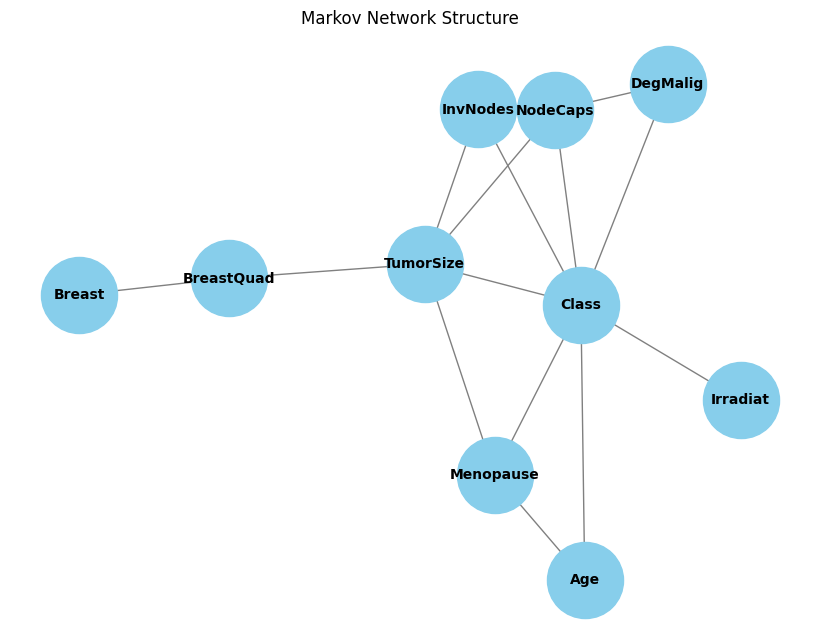

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
G = nx.Graph()
G.add_edges_from(edges)

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue', font_size=10, font_weight='bold', edge_color='gray')
plt.title("Markov Network Structure")
plt.show()